## mlpi26_Lect09_nbsup1.ipynb

# Classifying images with deep CNNs — a PCB solder-joint inspector

**Companion notebook to the lecture *Classifying images with deep convolutional neural
networks*.**

Everything here runs on CPU in about seven minutes and downloads nothing: the images are
drawn analytically from a model of how an AOI camera sees a chip-component solder joint.

## The running example

An inline **AOI (automated optical inspection)** station on an SMT line photographs every
0603 chip component after reflow. Each 64×64 RGB crop is centred on one two-pad footprint,
and has to be sorted into four classes:

| class | what it is | why it matters |
|---|---|---|
| `good` | correct concave fillet on both pads | ship it |
| `insufficient` | too little solder, bare gold pad still showing | weak joint, fails on thermal cycling |
| `bridge` | solder spans the gap between the pads | a short — the board does not work |
| `excess` | convex blob spilling past the pad edge | usually cosmetic, but hides real defects |

Two facts about the data drive the whole lecture, and both are true of real inspection data:

1. **The joint never appears twice at the same address.** Board registration, placement
   tolerance and magnification all move it around. A classifier that reads fixed pixel
   positions has no chance.
2. **Your labelled set is narrower than production.** You labelled 480 images from one
   afternoon on one line under one lamp. The line will then hand the model every shift,
   every lamp and every board. We build that split into the data deliberately, and it is
   what makes the last third of this notebook interesting.

## Learning objectives

By the end you should be able to:

1. Compute a discrete convolution in 1-D and 2-D by hand, and say what padding and stride do.
2. Use $o=\lfloor (n+2p-m)/s \rfloor + 1$ to predict the shape of every tensor in a CNN
   before you run it.
3. Explain sparse connectivity and parameter sharing, and count the parameters they save.
4. Say what max-pooling buys you, and measure it.
5. Build, train and evaluate a CNN in `torch.nn`, choosing the right loss for the task.
6. Tell apart the two reasons a model generalises badly — too much capacity, and a training
   set that does not cover production — and pick the fix that matches.

## Prerequisites

Tensors, `nn.Module`, `DataLoader` and the training loop from the previous two lectures;
matrix arithmetic; `numpy` basics.

---
## 0. Environment

In [1]:
import sys, platform, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import scipy.signal
from torch.utils.data import DataLoader, TensorDataset

print("python     ", sys.version.split()[0], "on", platform.system())
print("torch      ", torch.__version__)
print("numpy      ", np.__version__)
print("scipy      ", scipy.__version__)
print("matplotlib ", matplotlib.__version__)
print("CUDA available:", torch.cuda.is_available())
torch.set_num_threads(min(8, torch.get_num_threads()))

python      3.11.15 on Linux
torch       2.14.0+cu130
numpy       2.4.4
scipy       1.17.1
matplotlib  3.10.9
CUDA available: False


In [2]:
SURF, INK2, GRID = "#fcfcfb", "#52514e", "#e1e0d9"
BLUE, ORANGE, AQUA, YELLOW, VIOLET, MUTED = ("#2a78d6", "#eb6834", "#1baf7a",
                                             "#eda100", "#4a3aa7", "#898781")
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.size": 10, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "lines.linewidth": 1.8,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

---
## 1. The data

The renderer below draws each crop analytically with soft (anti-aliased) masks: board,
silkscreen, two gold pads, the ceramic body with its metallised end caps, the solder, and
whatever clutter — neighbouring footprints, vias, silkscreen text — happens to fall inside
the frame. Read it: knowing exactly what produced the labels is what lets us say later
whether a model *should* have been able to get them right.

The `REGIME` table is the important part. `narrow` is one afternoon on one line;
`full` is the whole production envelope.

In [3]:
IMG_H = IMG_W = 64
CLASSES = ["good", "insufficient", "bridge", "excess"]

FR4    = np.array([0.085, 0.300, 0.150])   # green solder resist
SILK   = np.array([0.880, 0.895, 0.860])   # white silkscreen
GOLD   = np.array([0.780, 0.625, 0.310])   # bare ENIG pad
SOLDER = np.array([0.700, 0.720, 0.760])   # SAC305 fillet
BODY   = np.array([0.130, 0.130, 0.155])   # ceramic body
CAP    = np.array([0.640, 0.650, 0.685])   # metallised end cap

PAD_DX, PAD_HW, PAD_HH = 14.0, 6.5, 10.0
BODY_HW, BODY_HH, CAP_W = 10.0, 8.5, 4.0
SCAN_ROW, EDGE = 38, 0.9

REGIME = {
    "narrow":    dict(rot=4.0,  shift=2.5, scale=(0.97, 1.03),
                      gain=(0.95, 1.08), grad=0.06, noise=(0.020, 0.030)),
    "full":      dict(rot=15.0, shift=9.0, scale=(0.88, 1.12),
                      gain=(0.70, 1.30), grad=0.25, noise=(0.020, 0.060)),
    "canonical": dict(rot=0.0,  shift=0.0, scale=(1.0, 1.0),
                      gain=(1.0, 1.0), grad=0.0, noise=(0.004, 0.004)),
}

In [4]:
def _smooth(d):
    '''Soft inside-mask from a signed distance (negative = inside).'''
    return np.clip(0.5 - d / EDGE, 0.0, 1.0)


def _rect(u, v, hw, hh, cu=0.0, cv=0.0):
    return _smooth(np.maximum(np.abs(u - cu) - hw, np.abs(v - cv) - hh))


def _ellipse(u, v, a, b, cu=0.0, cv=0.0):
    r = np.sqrt(((u - cu) / a) ** 2 + ((v - cv) / b) ** 2)
    return _smooth((r - 1.0) * min(a, b))


def _over(img, mask, colour):
    m = mask[..., None]
    return img * (1.0 - m) + np.asarray(colour) * m


def render_joint(label, rng, regime="full"):
    '''One 64x64x3 AOI crop of a solder joint of the given class.'''
    r = REGIME[regime]
    theta = np.deg2rad(rng.uniform(-r["rot"], r["rot"]))
    tx, ty = rng.uniform(-r["shift"], r["shift"], 2)
    scale = rng.uniform(*r["scale"])
    gain = rng.uniform(*r["gain"])
    grad = rng.uniform(-r["grad"], r["grad"], 2)
    noise = rng.uniform(*r["noise"])

    y, x = np.mgrid[0:IMG_H, 0:IMG_W].astype(np.float64)
    xc, yc = x - (IMG_W - 1) / 2 - tx, y - (IMG_H - 1) / 2 - ty
    ct, st = np.cos(-theta), np.sin(-theta)
    u = (xc * ct - yc * st) / scale                 # footprint frame
    v = (xc * st + yc * ct) / scale

    img = np.empty((IMG_H, IMG_W, 3)); img[:] = FR4
    img += rng.normal(0, 0.012, (IMG_H, IMG_W, 1)) * np.array([0.6, 1.0, 0.7])

    silk = _rect(u, v, 24.0, 14.0) - _rect(u, v, 22.6, 12.6)
    img = _over(img, np.clip(silk, 0, 1) * 0.85, SILK)

    # clutter: neighbouring footprints, vias, silkscreen text
    for _ in range(rng.integers(0, 3)):
        nu, nv = rng.uniform(-46, 46), rng.uniform(-46, 46)
        if abs(nu) < 30 and abs(nv) < 26:
            continue
        neigh = (_rect(u, v, PAD_HW, PAD_HH, cu=nu - 13, cv=nv) +
                 _rect(u, v, PAD_HW, PAD_HH, cu=nu + 13, cv=nv))
        img = _over(img, np.clip(neigh, 0, 1), GOLD)
        img = _over(img, _rect(u, v, 9.0, 8.0, cu=nu, cv=nv), BODY)
    if rng.random() < 0.6:
        vu, vv = rng.uniform(-30, 30), rng.uniform(22, 30) * rng.choice([-1, 1])
        img = _over(img, _ellipse(u, v, 3.2, 3.2, cu=vu, cv=vv), GOLD)
        img = _over(img, _ellipse(u, v, 1.5, 1.5, cu=vu, cv=vv), FR4 * 0.5)
    if rng.random() < 0.5:
        tu, tv = rng.uniform(-22, 22), rng.uniform(17, 27) * rng.choice([-1, 1])
        for k in range(rng.integers(2, 4)):
            img = _over(img, _rect(u, v, 1.1, 2.6, cu=tu + k * 3.4, cv=tv) * 0.9, SILK)

    pad_l = _rect(u, v, PAD_HW, PAD_HH, cu=-PAD_DX)
    pad_r = _rect(u, v, PAD_HW, PAD_HH, cu=+PAD_DX)
    img = _over(img, pad_l + pad_r, GOLD)

    def fillet(sign):
        cu = sign * PAD_DX
        if label == 1:                                  # insufficient
            return _ellipse(u, v, PAD_HW * 0.80, PAD_HH * 0.76, cu=cu + sign * 1.8)
        if label == 3:                                  # excess
            return _ellipse(u, v, PAD_HW * 1.18, PAD_HH * 1.10, cu=cu)
        core = _ellipse(u, v, PAD_HW * 0.95, PAD_HH * 0.92, cu=cu)
        wedge = _rect(u, v, 3.0, PAD_HH * 0.55, cu=cu - sign * 5.0)
        return np.clip(core + wedge, 0, 1)

    solder = np.clip(fillet(-1) + fillet(+1), 0, 1)
    img = _over(img, solder, SOLDER)

    img = _over(img, _rect(u, v, BODY_HW, BODY_HH), BODY)
    caps = (_rect(u, v, CAP_W / 2, BODY_HH, cu=-(BODY_HW - CAP_W / 2)) +
            _rect(u, v, CAP_W / 2, BODY_HH, cu=+(BODY_HW - CAP_W / 2)))
    img = _over(img, np.clip(caps, 0, 1), CAP)

    if label == 2:                                      # the bridge
        band = _rect(u, v, 8.5, 1.7, cv=5.4)
        img = _over(img, band * 0.92, SOLDER)
        solder = np.clip(solder + band, 0, 1)

    hl = rng.uniform(-1.6, 1.6, 2)                      # specular highlight
    if label == 3:
        spec = np.clip(sum(_ellipse(u, v, 2.6, 2.4, cu=s * PAD_DX - 2.0 + hl[0],
                                    cv=-2.5 + hl[1]) for s in (-1, 1)), 0, 1) * 0.85
    elif label == 1:
        spec = np.clip(sum(_ellipse(u, v, 1.5, 1.2, cu=s * (PAD_DX + 2.6) + hl[0],
                                    cv=hl[1]) for s in (-1, 1)), 0, 1) * 0.55
    else:
        spec = np.clip(sum(_rect(u, v, 4.6, 1.1, cu=s * PAD_DX + hl[0],
                                 cv=-4.0 + hl[1]) for s in (-1, 1)), 0, 1) * 0.8
        if label == 2:
            spec = np.clip(spec + _rect(u, v, 7.0, 0.6, cv=4.6) * 0.5, 0, 1)
    img = img + (spec * solder)[..., None] * 0.30

    field = 1.0 + grad[0] * (x / IMG_W - 0.5) + grad[1] * (y / IMG_H - 0.5)
    img = img * (gain * field)[..., None]
    img = img + rng.normal(0, noise, img.shape)
    return np.clip(img, 0.0, 1.0).astype(np.float32)


def make_dataset(n, seed=7, regime="full"):
    '''n images as float32 NCHW in [0,1], plus int64 labels.'''
    rng = np.random.default_rng(seed)
    labels = np.tile(np.arange(len(CLASSES)), n // len(CLASSES) + 1)[:n]
    rng.shuffle(labels)
    x = np.stack([render_joint(int(l), rng, regime) for l in labels])
    return np.transpose(x, (0, 3, 1, 2)).copy(), labels.astype(np.int64)


print("renderer ready")

renderer ready


In [5]:
# the labelled set and its validation split come from one afternoon;
# the test set is the production envelope
x_train, y_train = make_dataset(480, seed=7,   regime="narrow")
x_valid, y_valid = make_dataset(240, seed=108, regime="narrow")
x_test,  y_test  = make_dataset(800, seed=209, regime="full")

for name, x, y in (("train", x_train, y_train), ("valid", x_valid, y_valid),
                   ("test ", x_test, y_test)):
    print(f"{name}  {x.shape}  {x.dtype}  range [{x.min():.2f}, {x.max():.2f}]"
          f"  class counts {np.bincount(y)}")

train  (480, 3, 64, 64)  float32  range [0.00, 1.00]  class counts [120 120 120 120]
valid  (240, 3, 64, 64)  float32  range [0.00, 1.00]  class counts [60 60 60 60]
test   (800, 3, 64, 64)  float32  range [0.00, 1.00]  class counts [200 200 200 200]


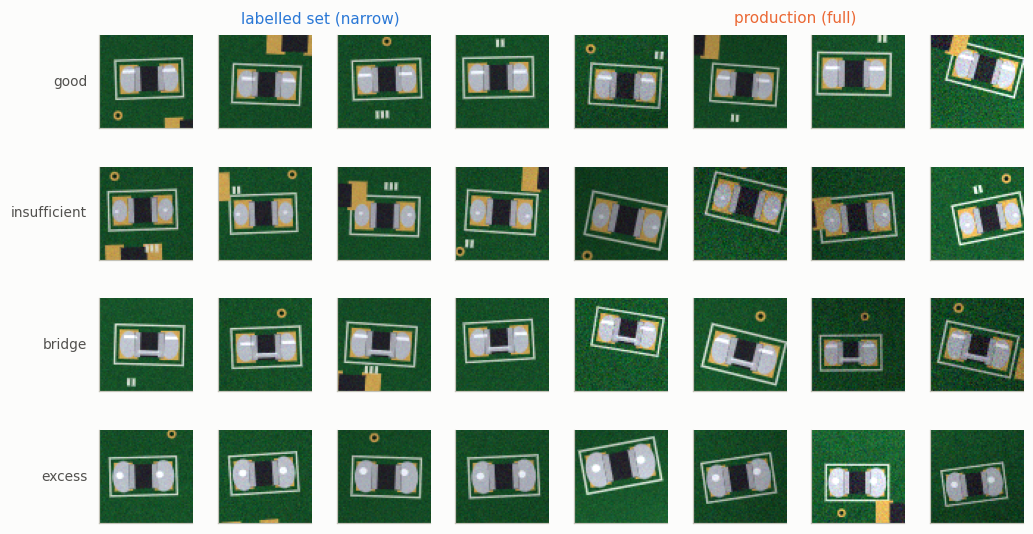

In [6]:
fig, axes = plt.subplots(4, 8, figsize=(9.5, 5.2))
rng = np.random.default_rng(12)
for r in range(4):
    for c in range(8):
        img = render_joint(r, rng, regime="narrow" if c < 4 else "full")
        axes[r, c].imshow(img)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([]); axes[r, c].grid(False)
    axes[r, 0].set_ylabel(CLASSES[r], fontsize=9, rotation=0, ha="right",
                          va="center", labelpad=8)
axes[0, 1].set_title("labelled set (narrow)", fontsize=10, color=BLUE, x=1.1, pad=8)
axes[0, 5].set_title("production (full)", fontsize=10, color=ORANGE, x=1.1, pad=8)
plt.tight_layout(); plt.show()

Look at the two halves. The classes are the same; the *nuisance* variation is not. Keep that
picture in mind — in section 11 four models will all score between 96 % and 100 % on the
left-hand distribution, and range from 38 % to 99 % on the right-hand one.

---
## 2. Discrete convolution in one dimension

A discrete convolution of a signal $x$ with a filter (kernel) $w$ is

$$y = x * w \;\rightarrow\; y[i] = \sum_{k=-\infty}^{+\infty} x[i-k]\,w[k]$$

Two things need fixing before that is computable. The infinite limits are handled by
**zero-padding** $x$ with $p$ zeros on each side; the negative indexing is handled by noting
that summing with one index running backwards is the same as flipping the filter and summing
both forwards. With padding $p$ and a filter of length $m$:

$$y[i] = \sum_{k=0}^{m-1} x^{p}[i+m-k]\,w[k]$$

**Cross-correlation vs convolution.** If you do *not* flip the filter you get
cross-correlation, $y[i]=\sum_k x[i+k]w[k]$. PyTorch (and every other deep-learning
framework) implements cross-correlation and calls it convolution. It makes no difference to
a network — the weights are learned either way, and a learned kernel is simply the flip of
the one you would have learned under the other convention — but it matters when you
hand-build a kernel, as we are about to.

### The signal: one scan row across the two pads

Row 38 of the crop runs through both solder fillets and through the gap between them. That
row alone is enough to detect a bridge.

In [7]:
def conv1d(x, w, p=0, s=1):
    '''Naive 1-D convolution, exactly as the formula above.'''
    w_rot = np.array(w[::-1])                    # flip: convolution, not correlation
    x_pad = np.array(x, dtype=float)
    if p > 0:
        x_pad = np.concatenate([np.zeros(p), x_pad, np.zeros(p)])
    out = []
    for i in range(0, int(len(x_pad) - len(w_rot)) + 1, s):
        out.append(np.sum(x_pad[i:i + w_rot.shape[0]] * w_rot))
    return np.array(out)


x_demo = [1, 3, 2, 4, 5, 6, 1, 3]
w_demo = [1, 0, 3, 1, 2]
print("conv1d      :", conv1d(x_demo, w_demo, p=2, s=1))
print("np.convolve :", np.convolve(x_demo, w_demo, mode="same"))
print("output size :", (len(x_demo) + 2 * 2 - len(w_demo)) // 1 + 1)

conv1d      : [ 5. 14. 16. 26. 24. 34. 19. 22.]
np.convolve : [ 5 14 16 26 24 34 19 22]
output size : 8


In [8]:
# mean intensity profile along the scan row, averaged over 24 perfectly
# registered parts of each class
rng = np.random.default_rng(11)
profiles = {}
for lab, name in enumerate(CLASSES):
    acc = [render_joint(lab, np.random.default_rng(rng.integers(10**6)),
                        regime="canonical")[SCAN_ROW].mean(axis=1)
           for _ in range(24)]
    profiles[name] = np.mean(acc, axis=0)

print("gap columns 26..37, mean intensity")
for k, v in profiles.items():
    print(f"  {k:<13s} pads {v[16:22].mean():.3f}   gap {v[28:36].mean():.3f}")

gap columns 26..37, mean intensity
  good          pads 0.727   gap 0.138
  insufficient  pads 0.645   gap 0.138
  bridge        pads 0.727   gap 0.680
  excess        pads 0.727   gap 0.139


There it is, in the numbers: every class has bright pads at ~0.72, and the gap is dark
(~0.14) for three of them and bright (~0.68) for a bridge. So the detector we want is a
filter that asks *"is the middle darker than the shoulders?"* — positive weights on the
solder shoulders, negative weights across the gap.

We make it **zero-sum** on purpose. A zero-sum kernel gives exactly zero on any flat region,
whatever its brightness, so the filter reports *structure* and ignores the lamp. That is the
single most useful property of a hand-designed kernel, and it is also what the first layer
of a trained CNN tends to discover on its own.

In [9]:
w_gap = np.array([1.0] * 4 + [-1.0] * 12 + [1.0] * 4)   # 20 taps: shoulders, gap
w_gap = w_gap - w_gap.mean()                             # make it zero-sum
w_gap = w_gap / np.abs(w_gap).sum()                      # and unit total weight
print("kernel:", np.round(w_gap, 4))
print("sum   :", round(float(w_gap.sum()), 12))

resp = {k: np.convolve(v, w_gap[::-1], mode="same") for k, v in profiles.items()}
print("\nresponse at the centre of the gap (column 32):")
for k, v in resp.items():
    print(f"  {k:<13s} {v[32]:+.4f}")

kernel: [ 0.0625  0.0625  0.0625  0.0625 -0.0417 -0.0417 -0.0417 -0.0417 -0.0417
 -0.0417 -0.0417 -0.0417 -0.0417 -0.0417 -0.0417 -0.0417  0.0625  0.0625
  0.0625  0.0625]
sum   : -0.0

response at the centre of the gap (column 32):
  good          +0.2599
  insufficient  +0.2601
  bridge        +0.0090
  excess        +0.2600


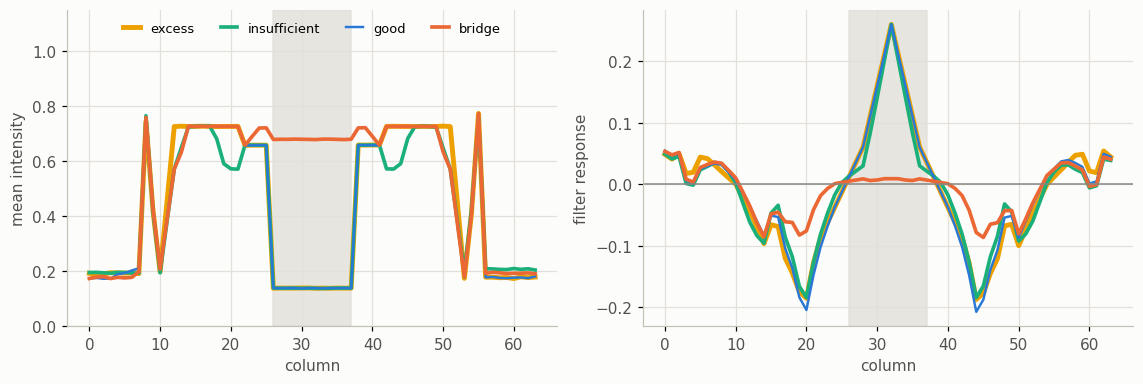

a single threshold at +0.134 separates bridge from everything else


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
CCOL = {"good": BLUE, "insufficient": AQUA, "excess": YELLOW, "bridge": ORANGE}
for name, lw in (("excess", 3.2), ("insufficient", 2.4), ("good", 1.6), ("bridge", 2.4)):
    axes[0].plot(profiles[name], color=CCOL[name], label=name, lw=lw)
    axes[1].plot(resp[name], color=CCOL[name], lw=lw)
for ax in axes:
    ax.axvspan(26, 37, color=GRID, alpha=.8, zorder=0)
    ax.set_xlabel("column")
axes[0].set_ylabel("mean intensity"); axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=8.5, ncol=4, loc="upper center", handlelength=1.3)
axes[1].axhline(0, color=MUTED, lw=1)
axes[1].set_ylabel("filter response")
plt.tight_layout(); plt.show()

thr = 0.5 * (resp["good"][32] + resp["bridge"][32])
print(f"a single threshold at {thr:+.3f} separates bridge from everything else")

---
## 3. Convolution in two dimensions

The same idea with two indices:

$$Y = X * W \;\rightarrow\; Y[i,j] = \sum_{k_1}\sum_{k_2} X[i-k_1,\, j-k_2]\, W[k_1,k_2]$$

Padding, stride and filter rotation all extend to both dimensions independently. The output
size is the 1-D formula applied per axis:

$$o = \left\lfloor \frac{n + 2p - m}{s} \right\rfloor + 1$$

### Three padding modes

| mode | $p$ | effect |
|---|---|---|
| **valid** | $0$ | output shrinks by $m-1$; stack enough layers and the tensor disappears |
| **same** | chosen so $o = n$ (for odd $m$, $s=1$: $p=(m-1)/2$) | spatial size preserved — the usual choice |
| **full** | $m-1$ | output *grows*; used in signal processing, almost never in CNNs |

The practical convention in a modern CNN is: **same padding on the convolutions, and reduce
the spatial size deliberately** with pooling or a stride-2 convolution. That way you always
know the shape, and you decide where the downsampling happens.

In [11]:
def conv2d(X, W, p=(0, 0), s=(1, 1)):
    '''Naive 2-D convolution, for understanding -- never for production.'''
    W_rot = np.array(W)[::-1, ::-1]
    X = np.array(X)
    n1, n2 = X.shape[0] + 2 * p[0], X.shape[1] + 2 * p[1]
    X_pad = np.zeros((n1, n2))
    X_pad[p[0]:p[0] + X.shape[0], p[1]:p[1] + X.shape[1]] = X
    out = []
    for i in range(0, (X_pad.shape[0] - W_rot.shape[0]) // s[0] + 1):
        out.append([])
        for j in range(0, (X_pad.shape[1] - W_rot.shape[1]) // s[1] + 1):
            sub = X_pad[i * s[0]:i * s[0] + W_rot.shape[0],
                        j * s[1]:j * s[1] + W_rot.shape[1]]
            out[-1].append(np.sum(sub * W_rot))
    return np.array(out)


X_demo = [[1, 3, 2, 4], [5, 6, 1, 3], [1, 2, 0, 2], [3, 4, 3, 2]]
W_demo = [[1, 0, 3], [1, 2, 1], [0, 1, 1]]
print("conv2d:\n", conv2d(X_demo, W_demo, p=(1, 1), s=(1, 1)))
print("\nscipy :\n", scipy.signal.convolve2d(X_demo, W_demo, mode="same"))

conv2d:
 [[11. 25. 32. 13.]
 [19. 25. 24. 13.]
 [13. 28. 25. 17.]
 [11. 17. 14.  9.]]

scipy :
 [[11 25 32 13]
 [19 25 24 13]
 [13 28 25 17]
 [11 17 14  9]]


In [12]:
def out_size(n, m, p, s):
    return (n + 2 * p - m) // s + 1


print(f"{'n':>4}{'m':>4}{'p':>4}{'s':>4}{'o':>6}   note")
for n, m, p, s, note in ((64, 3, 1, 1, "same padding: size preserved"),
                         (64, 3, 0, 1, "valid: shrinks by m-1"),
                         (64, 5, 2, 1, "same padding for a 5x5 kernel"),
                         (64, 2, 0, 2, "the 2x2 max-pool"),
                         (64, 3, 1, 2, "stride-2 conv: pooling with weights")):
    print(f"{n:>4}{m:>4}{p:>4}{s:>4}{out_size(n, m, p, s):>6}   {note}")

# and PyTorch agrees
probe = torch.ones(1, 3, 64, 64)
for layer, label in ((nn.Conv2d(3, 16, 3, padding=1), "Conv2d(3,16,3,padding=1)"),
                     (nn.Conv2d(3, 16, 3), "Conv2d(3,16,3)  [valid]"),
                     (nn.MaxPool2d(2), "MaxPool2d(2)")):
    print(f"{label:<28s} -> {tuple(layer(probe).shape)}")

   n   m   p   s     o   note
  64   3   1   1    64   same padding: size preserved
  64   3   0   1    62   valid: shrinks by m-1
  64   5   2   1    64   same padding for a 5x5 kernel
  64   2   0   2    32   the 2x2 max-pool
  64   3   1   2    32   stride-2 conv: pooling with weights
Conv2d(3,16,3,padding=1)     -> (1, 16, 64, 64)
Conv2d(3,16,3)  [valid]      -> (1, 16, 62, 62)
MaxPool2d(2)                 -> (1, 3, 32, 32)


---
## 4. A kernel is a feature detector

Nine numbers is all a 3×3 kernel is. Here are four classic ones applied to a bridged joint.
Nothing about them is special to image processing folklore — they are simply the weight
patterns that respond to a particular local structure, and the point of a CNN is that it
**learns** these instead of being told them.

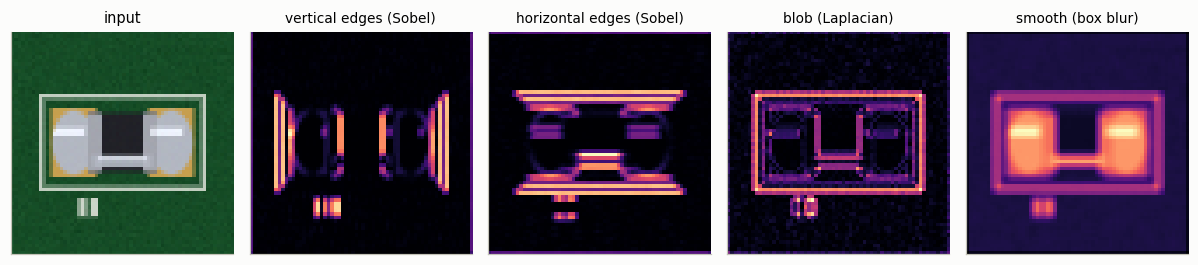

vertical edges (Sobel)     sum of weights = +0.00
horizontal edges (Sobel)   sum of weights = +0.00
blob (Laplacian)           sum of weights = +0.00
smooth (box blur)          sum of weights = +1.00


In [13]:
img_bridge = render_joint(2, np.random.default_rng(4), regime="canonical")
t = torch.tensor(img_bridge.transpose(2, 0, 1))[None]
grey = t.mean(1, keepdim=True)                 # one channel, for the demo

kernels = {
    "vertical edges (Sobel)":   [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    "horizontal edges (Sobel)": [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
    "blob (Laplacian)":         [[0, -1, 0], [-1, 4, -1], [0, -1, 0]],
    "smooth (box blur)":        [[1 / 9] * 3] * 3,
}
fig, axes = plt.subplots(1, 5, figsize=(11, 2.6))
axes[0].imshow(img_bridge); axes[0].set_title("input", fontsize=9.5)
for ax, (name, k) in zip(axes[1:], kernels.items()):
    kt = torch.tensor(k, dtype=torch.float32)[None, None]
    out = F.conv2d(grey, kt, padding=1)[0, 0].abs()
    ax.imshow(out / out.max(), cmap="magma")
    ax.set_title(name, fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

for name, k in kernels.items():
    print(f"{name:<26s} sum of weights = {np.sum(k):+.2f}")

Note which kernels sum to zero. The three edge and blob detectors do, so they are blind to
overall brightness and respond only to structure — exactly the property we built into the
1-D gap kernel. The box blur sums to one, so it preserves brightness and destroys structure.

> **`F.conv2d` is cross-correlation.** If you want a true convolution with a kernel you
> designed, flip it first: `kt.flip(-1, -2)`. For symmetric kernels like the Laplacian it
> makes no difference; for the Sobel pair it flips the sign.

---
## 5. Subsampling: pooling layers

Pooling replaces each neighbourhood by one number — its maximum (**max-pooling**) or its
average (**mean-pooling**). It has **no trainable parameters at all**. It buys two things:

1. **Local translation invariance.** Max-pooling reports "the strongest response anywhere in
   this window", so a shift that does not move the winner out of its window changes the
   output not at all.
2. **Cheaper everything.** Halving both spatial dimensions quarters the work of every layer
   above.

Traditionally windows do not overlap (stride = pooling size, which is PyTorch's default when
you leave `stride` unset). Overlapping pooling exists — AlexNet used it — and some modern
architectures drop pooling entirely in favour of stride-2 convolutions, which you can think
of as *pooling with learnable weights*.

In [14]:
rng = np.random.default_rng(2)
patch = torch.tensor(np.round(rng.uniform(0, 9, (1, 1, 4, 4))), dtype=torch.float32)
print("feature map:\n", patch[0, 0].numpy().astype(int))
print("\nmax-pool 2x2:\n", F.max_pool2d(patch, 2)[0, 0].numpy())
print("\nmean-pool 2x2:\n", F.avg_pool2d(patch, 2)[0, 0].numpy().round(2))

feature map:
 [[2 3 7 1]
 [5 7 2 0]
 [2 6 5 1]
 [4 6 4 6]]

max-pool 2x2:
 [[7. 7.]
 [6. 6.]]

mean-pool 2x2:
 [[4.25 2.5 ]
 [4.5  4.  ]]


In [15]:
# how much of the representation survives a one-pixel shift of the whole part?
img = render_joint(0, np.random.default_rng(5), regime="canonical")
t = torch.tensor(img.transpose(2, 0, 1))[None]
shifted = torch.roll(t, shifts=1, dims=-1)

print(f"{'operation':<22}{'values identical':>18}")
print(f"{'raw pixels':<22}{((t - shifted).abs() < 1e-6).float().mean() * 100:>17.1f} %")
for k in (2, 4, 8):
    a, b = F.max_pool2d(t, k), F.max_pool2d(shifted, k)
    print(f"{'max-pool ' + str(k) + 'x' + str(k):<22}"
          f"{((a - b).abs() < 1e-6).float().mean() * 100:>17.1f} %")

operation               values identical
raw pixels                          0.0 %
max-pool 2x2                       31.5 %
max-pool 4x4                       53.6 %
max-pool 8x8                       68.2 %


Read the last number carefully: after a 4×4 max-pool, more than half of the representation
is **bit-identical** after moving the part, while essentially none of the raw pixels are.
That is the invariance the dense network in section 10 has to buy with training data instead.

---
## 6. Channels, and the parameter argument

An image is a rank-3 tensor $X_{N_1\times N_2\times C_{in}}$. A convolutional layer holds a
rank-4 kernel tensor $W_{m_1\times m_2\times C_{in}\times C_{out}}$: **one kernel per output
channel, each spanning every input channel**. For output map $k$:

$$Z[:,:,k] = \sum_{c=1}^{C_{in}} W[:,:,c,k] * X[:,:,c] \;+\; b[k],
\qquad A[:,:,k] = \sigma(Z[:,:,k])$$

PyTorch stores images as **NCHW** — batch, channel, height, width. (TensorFlow uses NHWC; if
your array has channels last, `np.transpose` before you make the tensor.)

The parameter count is where sparse connectivity and parameter sharing pay off, and the size
of the effect is hard to believe until you compute it.

In [16]:
n1, n2 = 64, 64
c_in, c_out, m = 3, 16, 3
conv_params = m * m * c_in * c_out + c_out
dense_params = (n1 * n2 * c_in) * (n1 * n2 * c_out) + n1 * n2 * c_out

print(f"3x3 conv, {c_in} -> {c_out} channels on {n1}x{n2}: {conv_params:>15,} parameters")
print(f"a dense layer with the same in and out:      {dense_params:>15,} parameters")
print(f"ratio: {dense_params / conv_params:,.0f}x")

layer = nn.Conv2d(c_in, c_out, m, padding=1)
print(f"\nPyTorch agrees: {sum(p.numel() for p in layer.parameters()):,}")
print("weight", tuple(layer.weight.shape), " bias", tuple(layer.bias.shape))

3x3 conv, 3 -> 16 channels on 64x64:             448 parameters
a dense layer with the same in and out:          805,371,904 parameters
ratio: 1,797,705x

PyTorch agrees: 448
weight (16, 3, 3, 3)  bias (16,)


The conv layer does not merely have fewer parameters — it has fewer parameters *and* a
better inductive bias. Sharing the same 9 weights across every position encodes the
assumption "a solder bridge looks the same wherever it appears", which is true, and which a
dense layer would have to learn separately for every pixel position from data you do not
have.

---
## 7. Choosing the loss

| task | last layer | loss | takes |
|---|---|---|---|
| binary | `Sigmoid` | `nn.BCELoss` | probabilities |
| binary | none | `nn.BCEWithLogitsLoss` | **logits — preferred** |
| multi-class | `LogSoftmax` | `nn.NLLLoss` | log-probabilities |
| multi-class | none | `nn.CrossEntropyLoss` | **logits — preferred** |

The logit versions are numerically stable: they fuse the log and the exponential so nothing
overflows when the model becomes confident. The two forms give the same number when nothing
overflows, which is what the next cell checks.

In [17]:
# binary
logits = torch.tensor([0.8])
probas = torch.sigmoid(logits)
target = torch.tensor([1.0])
print(f"BCE from probabilities : {nn.BCELoss()(probas, target):.4f}")
print(f"BCE from logits        : {nn.BCEWithLogitsLoss()(logits, target):.4f}")

# multi-class: our four defect classes
logits = torch.tensor([[1.5, 0.8, 2.1, -0.3]])
target = torch.tensor([2])                       # 'bridge'
print(f"\nNLL  from log-probabilities: "
      f"{nn.NLLLoss()(torch.log_softmax(logits, dim=1), target):.4f}")
print(f"CrossEntropy from logits   : {nn.CrossEntropyLoss()(logits, target):.4f}")

BCE from probabilities : 0.3711
BCE from logits        : 0.3711

NLL  from log-probabilities: 0.6482
CrossEntropy from logits   : 0.6482


The classic mistake, worth recognising on sight:

```python
# WRONG -- softmax applied twice; gradients squash and training crawls,
#          but nothing raises an error
model = nn.Sequential(nn.Linear(64, 4), nn.Softmax(dim=1))
loss_fn = nn.CrossEntropyLoss()

# RIGHT -- the loss applies log-softmax internally
model = nn.Sequential(nn.Linear(64, 4))
loss_fn = nn.CrossEntropyLoss()
```

`CrossEntropyLoss` also takes integer class labels directly (`y = 2`), not one-hot vectors.

---
## 8. Building the CNN

Four convolution blocks, each `Conv2d(3×3, same padding) → ReLU → MaxPool2d(2)`, with the
channel count doubling as the spatial size halves. Then a **global average pooling** layer,
which collapses each 8×8 feature map to its mean, turning `64 × 8 × 8` into a 64-vector.

Global average pooling instead of `Flatten` is worth dwelling on. Flattening `64 × 8 × 8`
gives 4096 inputs, and a dense layer on top of that would hold 16 000 parameters — more than
a quarter of the whole network, all of them position-specific, which is exactly the
inductive bias we just spent six sections avoiding. Global average pooling asks "how strongly
does this feature appear *anywhere* in the frame?", needs no parameters, and works for any
input size.

The habit to copy: **check the shapes with a dummy batch before you train anything.**

In [18]:
def build_cnn(p_drop=0.0):
    layers = [
        nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 32x32
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16x16
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        nn.AdaptiveAvgPool2d(1), nn.Flatten(),                        # 64
    ]
    if p_drop > 0:
        layers += [nn.Dropout(p_drop)]
    layers += [nn.Linear(64, len(CLASSES))]      # raw logits, no Softmax
    return nn.Sequential(*layers)


def build_mlp(p_drop=0.0):
    layers = [nn.Flatten(), nn.Linear(3 * 64 * 64, 256), nn.ReLU()]
    if p_drop > 0:
        layers += [nn.Dropout(p_drop)]
    layers += [nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, len(CLASSES))]
    return nn.Sequential(*layers)


n_params = lambda m: sum(p.numel() for p in m.parameters())

cnn, mlp = build_cnn(0.3), build_mlp(0.3)
probe = torch.ones(4, 3, 64, 64)
h = probe
for layer in cnn:
    h = layer(h)
    print(f"{layer.__class__.__name__:<18} -> {tuple(h.shape)}")
print(f"\nCNN {n_params(cnn):>10,} parameters")
print(f"MLP {n_params(mlp):>10,} parameters   ({n_params(mlp)/n_params(cnn):.0f}x more)")

Conv2d             -> (4, 16, 64, 64)
ReLU               -> (4, 16, 64, 64)
MaxPool2d          -> (4, 16, 32, 32)
Conv2d             -> (4, 32, 32, 32)
ReLU               -> (4, 32, 32, 32)
MaxPool2d          -> (4, 32, 16, 16)
Conv2d             -> (4, 64, 16, 16)
ReLU               -> (4, 64, 16, 16)
MaxPool2d          -> (4, 64, 8, 8)
Conv2d             -> (4, 64, 8, 8)
ReLU               -> (4, 64, 8, 8)
AdaptiveAvgPool2d  -> (4, 64, 1, 1)
Flatten            -> (4, 64)
Dropout            -> (4, 64)
Linear             -> (4, 4)

CNN     60,772 parameters
MLP  3,179,396 parameters   (52x more)


---
## 9. Regularisation, and the two very different problems it solves

**L2 / weight decay** adds $\lambda\sum w^2$ to the loss, shrinking weights toward zero. In
PyTorch you normally pass `weight_decay=` to the optimizer rather than building the penalty
by hand — for SGD the two are equivalent.

**Dropout** zeroes each unit with probability $p$ during training only. The network cannot
rely on any one unit, so it learns a redundant representation. It is usefully read as an
ensemble: each mini-batch trains a different sub-network sampled from $2^h$ of them, and at
inference you use all units. PyTorch implements *inverse dropout* — it scales the surviving
activations by $1/(1-p)$ during training — so **you must switch modes**: `model.train()`
before the training loop and `model.eval()` before evaluating. Forgetting `eval()` is the
single most common silent bug in this chapter's material.

In [19]:
# building the L2 penalty by hand, to see what weight_decay does
conv = nn.Conv2d(3, 16, 3)
l2_lambda = 1e-4
l2_penalty = l2_lambda * sum((p ** 2).sum() for p in conv.parameters())
print(f"L2 penalty on one conv layer at init: {l2_penalty.item():.6f}")
print("in practice: torch.optim.Adam(model.parameters(), lr=..., weight_decay=1e-4)")

# dropout only fires in training mode
torch.manual_seed(0)
drop = nn.Dropout(p=0.5)
v = torch.ones(1, 8)
drop.train(); print("\ntrain mode:", drop(v).numpy().round(2), " <- zeroed and rescaled")
drop.train(); print("train mode:", drop(v).numpy().round(2), " <- different again")
drop.eval();  print("eval  mode:", drop(v).numpy().round(2), " <- identity")

L2 penalty on one conv layer at init: 0.000530
in practice: torch.optim.Adam(model.parameters(), lr=..., weight_decay=1e-4)

train mode: [[0. 0. 2. 0. 0. 0. 2. 2.]]  <- zeroed and rescaled
train mode: [[0. 2. 2. 2. 2. 0. 2. 2.]]  <- different again
eval  mode: [[1. 1. 1. 1. 1. 1. 1. 1.]]  <- identity


---
## 10. Data augmentation

Augmentation applies random, **label-preserving** transformations to the training images. A
transformation is label-preserving only if it reflects a symmetry the real process has — that
is the whole design rule, and getting it wrong destroys accuracy rather than improving it.
For this inspection task:

| transform | why it is legitimate here |
|---|---|
| horizontal / vertical flip | the footprint is symmetric and boards arrive either way round |
| rotation ±15° | placement tolerance plus board registration |
| translation ±9 px | board registration |
| brightness / contrast jitter | ring-light output drifts as the lamp ages |

And what would **not** be legitimate: a large rotation on a polarised component, where
orientation *is* the defect; or a colour shift so strong that gold pad and silver solder
become indistinguishable, because that is the very cue `insufficient` depends on.

We implement it with `F.affine_grid` / `F.grid_sample` so the notebook stays dependency-free
and you can see the mechanism. In a project you would write the same thing as a
`torchvision.transforms.v2` pipeline:

```python
from torchvision.transforms import v2
train_tf = v2.Compose([
    v2.RandomHorizontalFlip(), v2.RandomVerticalFlip(),
    v2.RandomAffine(degrees=15, translate=(0.14, 0.14)),
    v2.ColorJitter(brightness=0.3, contrast=0.2),
])
```

**Augment the training set only** — never the validation or test set. The test set is meant
to be a picture of production; perturbing it makes your headline number meaningless.

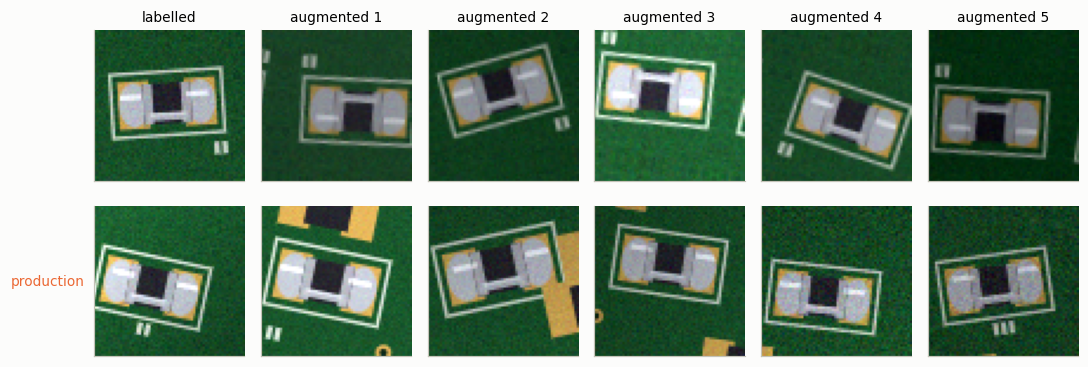

In [20]:
def augment(x, gen):
    '''Random flips, small rotation/translation, and lighting jitter.'''
    n, dev = x.shape[0], x.device
    flip_h = torch.rand(n, generator=gen, device=dev) < 0.5
    x = torch.where(flip_h[:, None, None, None], x.flip(-1), x)
    flip_v = torch.rand(n, generator=gen, device=dev) < 0.5
    x = torch.where(flip_v[:, None, None, None], x.flip(-2), x)

    ang = (torch.rand(n, generator=gen, device=dev) * 2 - 1) * np.deg2rad(15.0)
    tx = (torch.rand(n, generator=gen, device=dev) * 2 - 1) * (9.0 / 32.0)
    ty = (torch.rand(n, generator=gen, device=dev) * 2 - 1) * (9.0 / 32.0)
    cos, sin = torch.cos(ang), torch.sin(ang)
    theta = torch.zeros(n, 2, 3, device=dev)
    theta[:, 0, 0], theta[:, 0, 1], theta[:, 0, 2] = cos, -sin, tx
    theta[:, 1, 0], theta[:, 1, 1], theta[:, 1, 2] = sin, cos, ty
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="reflection",
                      align_corners=False)

    gain = 1.0 + (torch.rand(n, 1, 1, 1, generator=gen, device=dev) * 2 - 1) * 0.30
    bias = (torch.rand(n, 1, 1, 1, generator=gen, device=dev) * 2 - 1) * 0.06
    return (x * gain + bias).clamp(0.0, 1.0)


base = torch.tensor(x_train[:1])
gen = torch.Generator().manual_seed(3)
fig, axes = plt.subplots(2, 6, figsize=(10, 3.6))
axes[0, 0].imshow(np.transpose(base[0].numpy(), (1, 2, 0)))
axes[0, 0].set_title("labelled", fontsize=9)
for c in range(1, 6):
    axes[0, c].imshow(np.transpose(augment(base, gen)[0].numpy(), (1, 2, 0)))
    axes[0, c].set_title(f"augmented {c}", fontsize=9)
rng2 = np.random.default_rng(31)
for c in range(6):
    axes[1, c].imshow(render_joint(int(y_train[0]), rng2, regime="full"))
axes[1, 0].set_ylabel("production", fontsize=9, color=ORANGE, rotation=0,
                      ha="right", va="center", labelpad=6)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

---
## 11. Four experiments

One training function, four configurations. Everything else — data, seeds, schedule, epochs —
is held fixed, so any difference in the last column is caused by the thing named in the first.

Note the checkpoint rule. Validation accuracy will saturate at 100 % for every model, so it
cannot be used to choose between epochs; cosine annealing takes the learning rate to ~0, so
we simply take the final epoch for all four. That is the fair, deterministic choice — and the
fact that we *cannot* select on validation is itself the warning this section is about.

This cell is the slow one: roughly four and a half minutes on a laptop CPU.

In [21]:
def train(model, epochs=90, lr=2e-3, bs=32, seed=1, aug=False, weight_decay=0.0):
    xtr, ytr = torch.tensor(x_train), torch.tensor(y_train)
    xva, yva = torch.tensor(x_valid), torch.tensor(y_valid)
    gen = torch.Generator().manual_seed(seed)
    dl = DataLoader(TensorDataset(xtr, ytr), batch_size=bs, shuffle=True, generator=gen)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    aug_gen = torch.Generator().manual_seed(seed + 5)
    hist = {k: [] for k in ("loss_tr", "acc_tr", "loss_va", "acc_va")}

    for ep in range(epochs):
        model.train()                       # dropout on
        tot_l = tot_a = 0.0
        for xb, yb in dl:
            if aug:
                xb = augment(xb, aug_gen)   # training images only
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
            tot_l += loss.item() * xb.size(0)
            tot_a += (logits.argmax(1) == yb).sum().item()
        sched.step()
        hist["loss_tr"].append(tot_l / len(ytr))
        hist["acc_tr"].append(tot_a / len(ytr))
        model.eval()                        # dropout off
        with torch.no_grad():
            lo = model(xva)
            hist["loss_va"].append(loss_fn(lo, yva).item())
            hist["acc_va"].append((lo.argmax(1) == yva).float().mean().item())
    return hist


@torch.no_grad()
def evaluate(model, x, y):
    model.eval()
    pred = model(torch.tensor(x)).argmax(1).numpy()
    cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
    for tr, pr in zip(y, pred):
        cm[tr, pr] += 1
    return (pred == y).mean(), cm


print("ready")

ready


In [22]:
SPECS = [
    ("dense MLP",                      "mlp", 0.3, False, 0.0),
    ("CNN, no regularisation",         "cnn", 0.0, False, 0.0),
    ("CNN + dropout + L2",             "cnn", 0.3, False, 1e-4),
    ("CNN + dropout + L2 + augment",   "cnn", 0.3, True,  1e-4),
]

results, t0 = {}, time.time()
for label, kind, p_drop, aug, wd in SPECS:
    torch.manual_seed(1)
    model = build_mlp(p_drop) if kind == "mlp" else build_cnn(p_drop)
    hist = train(model, aug=aug, weight_decay=wd)
    acc, cm = evaluate(model, x_test, y_test)
    results[label] = {"hist": hist, "test": acc, "cm": cm, "model": model,
                      "params": n_params(model)}
    print(f"{label:<32s} train {hist['acc_tr'][-1]:.3f}"
          f"   valid {hist['acc_va'][-1]:.3f}   TEST {acc:.4f}")
print(f"\n{time.time() - t0:.0f} s total")

dense MLP                        train 0.992   valid 0.958   TEST 0.3787


CNN, no regularisation           train 1.000   valid 1.000   TEST 0.8425


CNN + dropout + L2               train 0.998   valid 1.000   TEST 0.8938


CNN + dropout + L2 + augment     train 0.994   valid 1.000   TEST 0.9875

268 s total


In [23]:
print(f"{'model':<32}{'params':>11}{'train':>8}{'valid':>8}{'production':>12}")
print("-" * 71)
for label, r in results.items():
    print(f"{label:<32}{r['params']:>11,}{r['hist']['acc_tr'][-1]:>8.3f}"
          f"{r['hist']['acc_va'][-1]:>8.3f}{r['test']:>11.1%}")

best = max(results, key=lambda k: results[k]["test"])
plain = results["CNN, no regularisation"]["test"]
print(f"\nCNN over MLP        : {results['CNN, no regularisation']['test'] - results['dense MLP']['test']:+.1%}"
      f"  with {results['dense MLP']['params'] / results['CNN, no regularisation']['params']:.0f}x FEWER parameters")
print(f"dropout + L2 adds   : {results['CNN + dropout + L2']['test'] - plain:+.1%}")
print(f"augmentation adds   : {results['CNN + dropout + L2 + augment']['test'] - plain:+.1%}")

model                                params   train   valid  production
-----------------------------------------------------------------------
dense MLP                         3,179,396   0.992   0.958      37.9%
CNN, no regularisation               60,772   1.000   1.000      84.2%
CNN + dropout + L2                   60,772   0.998   1.000      89.4%
CNN + dropout + L2 + augment         60,772   0.994   1.000      98.8%

CNN over MLP        : +46.4%  with 52x FEWER parameters
dropout + L2 adds   : +5.1%
augmentation adds   : +14.5%


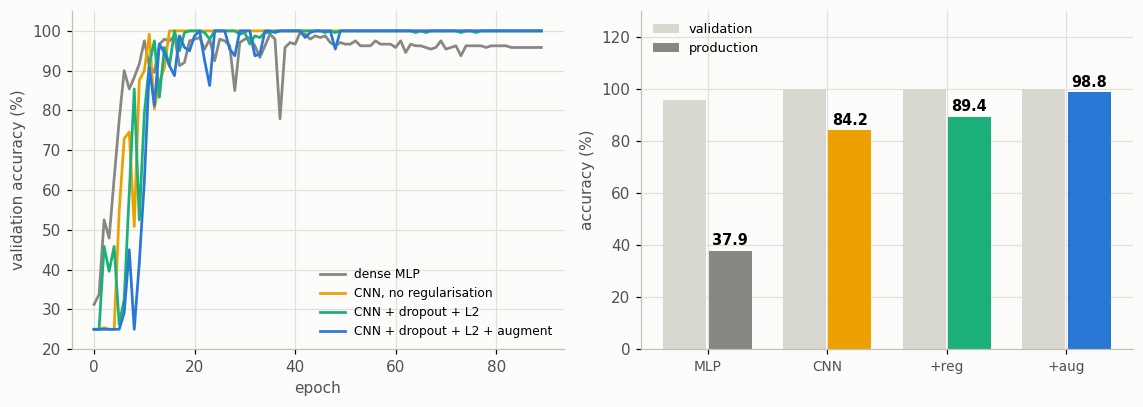

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
COL = {"dense MLP": MUTED, "CNN, no regularisation": YELLOW,
       "CNN + dropout + L2": AQUA, "CNN + dropout + L2 + augment": BLUE}
for label, r in results.items():
    axes[0].plot(np.array(r["hist"]["acc_va"]) * 100, color=COL[label], label=label)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation accuracy (%)")
axes[0].set_ylim(20, 105); axes[0].legend(fontsize=8, loc="lower right")

xs = np.arange(len(results))
va = [r["hist"]["acc_va"][-1] * 100 for r in results.values()]
te = [r["test"] * 100 for r in results.values()]
axes[1].bar(xs - .19, va, .36, color="#d8d7d0", label="validation")
axes[1].bar(xs + .19, te, .36, color=[COL[k] for k in results], label="production")
for i, t_ in enumerate(te):
    axes[1].text(i + .19, t_ + 2, f"{t_:.1f}", ha="center", fontsize=9.5,
                 fontweight="bold")
axes[1].set_xticks(xs)
axes[1].set_xticklabels(["MLP", "CNN", "+reg", "+aug"], fontsize=9)
axes[1].set_ylabel("accuracy (%)"); axes[1].set_ylim(0, 130)
axes[1].legend(fontsize=8.5, loc="upper left")
plt.tight_layout(); plt.show()

### Reading the table

Three separate lessons, and they do not have the same fix.

**The MLP fails for a structural reason.** It has 52× *more* parameters than the CNN and gets
less than half the accuracy. Both models fit the labelled set perfectly; only the CNN has the
inductive bias — parameter sharing plus pooling — that lets it recognise a bridge at a
position it never saw during training.

**Validation is blind to all of it.** Every model scores 96 % or better on the validation
split — the three CNNs score exactly 100 % — because that split came from the same afternoon
as the training set. A validation set
drawn from the same narrow slice as your training data measures *optimisation*, not
generalisation. If your model is going to be deployed, hold out data that looks like
deployment.

**Dropout and augmentation fix different things.** Dropout and L2 reduce variance from having
too many parameters for the data; they buy a few points here. Augmentation manufactures the
*distribution* the labelled set never contained, and it buys far more. Diagnosing which of
the two problems you have — too much model, or too narrow a dataset — is the difference
between a fix that works and a month of tuning that does not.

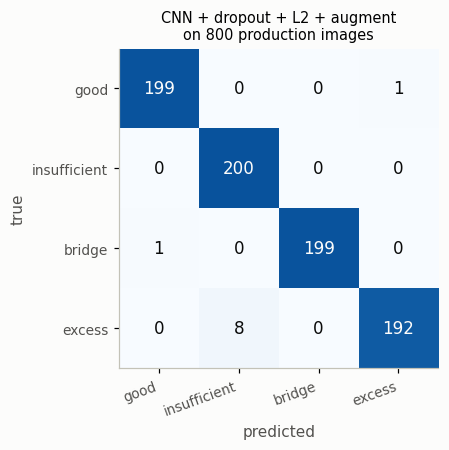

good          recall  99.5%   missed   1 of 200
insufficient  recall 100.0%   missed   0 of 200
bridge        recall  99.5%   missed   1 of 200
excess        recall  96.0%   missed   8 of 200


In [25]:
cm = results[best]["cm"]
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max() * 1.15)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                color=SURF if i == j else "#0b0b0b")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(CLASSES, rotation=20, ha="right", fontsize=9)
ax.set_yticklabels(CLASSES, fontsize=9)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.grid(False)
ax.set_title(f"{best}\non {len(y_test)} production images", fontsize=9.5)
plt.tight_layout(); plt.show()

for i, c in enumerate(CLASSES):
    recall = cm[i, i] / cm[i].sum()
    print(f"{c:<13s} recall {recall:6.1%}   missed {cm[i].sum() - cm[i, i]:>3d} of {cm[i].sum()}")

For an inspection station the confusion matrix matters more than the headline accuracy,
because the two error directions cost completely different amounts. Calling a good joint
defective costs an operator thirty seconds at the rework bench. Calling a **bridge** good
ships a shorted board, which is caught at functional test if you are lucky and by the
customer if you are not. In production you would bias the decision threshold accordingly
rather than taking the raw `argmax`.

---
## 12. What did the network actually learn?

The first convolution layer holds sixteen 3×3×3 kernels. Plotting them as RGB images shows
what colour and orientation each responds to, and pushing a real production frame through
shows what they produce.

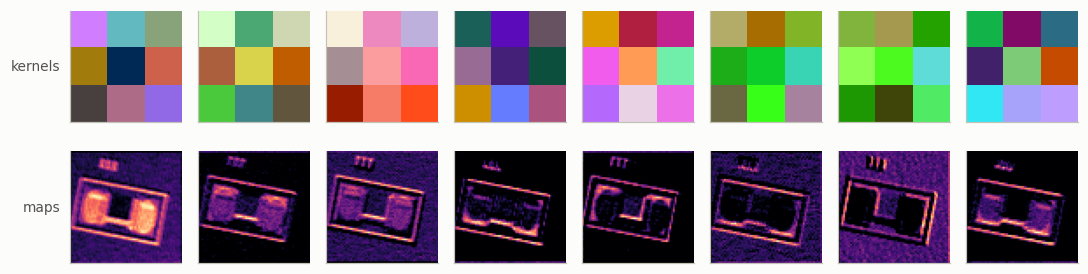

feature-map shapes through the network:
  after ReLU 1: (1, 16, 64, 64)
  after ReLU 2: (1, 32, 32, 32)
  after ReLU 3: (1, 64, 16, 16)
  after ReLU 4: (1, 64, 8, 8)


In [26]:
model = results[best]["model"]
model.eval()
w0 = model[0].weight.detach()

img = torch.tensor(render_joint(2, np.random.default_rng(9), regime="full")
                   .transpose(2, 0, 1))[None]
acts, h = [], img
with torch.no_grad():
    for layer in model:
        h = layer(h)
        if isinstance(layer, nn.ReLU):
            acts.append(h.clone())

wn = (w0 - w0.amin(dim=(1, 2, 3), keepdim=True))
wn = wn / wn.amax(dim=(1, 2, 3), keepdim=True).clamp_min(1e-9)

fig, axes = plt.subplots(2, 8, figsize=(10, 2.9))
for i in range(8):
    axes[0, i].imshow(np.transpose(wn[i].numpy(), (1, 2, 0)), interpolation="nearest")
top = acts[0][0].amax(dim=(1, 2)).argsort(descending=True)[:8]
for i, ch in enumerate(top):
    axes[1, i].imshow(acts[0][0, ch].numpy(), cmap="magma")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[0, 0].set_ylabel("kernels", fontsize=9, rotation=0, ha="right", va="center", labelpad=6)
axes[1, 0].set_ylabel("maps", fontsize=9, rotation=0, ha="right", va="center", labelpad=6)
plt.tight_layout(); plt.show()

print("feature-map shapes through the network:")
for i, a in enumerate(acts):
    print(f"  after ReLU {i + 1}: {tuple(a.shape)}")

Nobody specified those kernels. The network discovered oriented edge detectors and
colour-contrast detectors — gold-against-green, silver-against-dark — because that is what
separates the four classes. This is the **feature hierarchy** claim made concrete: the early
layers find edges and blobs, and the later ones combine them into "fillet present", "gap
bridged", and finally into a class.

---
## 13. A note on transfer learning

We trained from scratch because the notebook has to run offline in a few minutes. On a real
inspection project with a few hundred labelled images you would almost certainly start from
a backbone pretrained on a large natural-image corpus, because its early layers already
contain the edge and texture detectors we just watched this network rediscover:

```python
from torchvision.models import resnet18, ResNet18_Weights
backbone = resnet18(weights=ResNet18_Weights.DEFAULT)   # downloads weights
for p in backbone.parameters():                          # freeze the features
    p.requires_grad = False
backbone.fc = nn.Linear(backbone.fc.in_features, 4)      # new, trainable head
# train the head first; then unfreeze the last block and fine-tune at a
# 10x smaller learning rate
```

Three caveats that matter on a factory floor. The pretrained normalisation statistics and
input size are part of the contract — feed it what it expects. A frozen backbone is fast to
train but cannot adapt to the fact that your images are lit by a ring light rather than the
sun, so fine-tuning the last block usually pays. And the backbone is often larger than the
whole network we built here, which is a real consideration when the model has to keep up with
a line running at one board a second.

None of this changes anything in sections 2–11: the mechanics are the same, you are just
starting from better initial kernels.

---
## 14. The protocol — what to remember

1. **Predict every shape before you run.** $o=\lfloor (n+2p-m)/s\rfloor+1$, then check with a
   dummy batch. Most CNN bugs are shape bugs.
2. **Same padding on convolutions; downsample deliberately** with pooling or stride-2 convs.
3. **Pooling has no parameters** and buys local translation invariance. Measure it once so
   you believe it.
4. **Never put a Softmax before `CrossEntropyLoss`**, and never a Sigmoid before
   `BCEWithLogitsLoss`.
5. **`model.train()` / `model.eval()` around everything**, or dropout and batch norm will
   quietly corrupt your validation numbers.
6. **Use global average pooling** instead of flattening into a wide dense layer, unless you
   have a reason not to.
7. **Augment the training set only**, and only with transformations that preserve the label
   in your process.
8. **Hold out data that looks like deployment.** A validation split from the same batch as
   your training set cannot tell you whether the model will work.
9. **Diagnose before you regularise.** Too many parameters for the data is one problem;
   a training set that does not cover production is a different one. Dropout fixes the first,
   augmentation and better sampling fix the second.
10. **Read the confusion matrix, not just the accuracy** — errors have different costs.

---
## 15. Exercises

1. **Convolution by hand.** Take $x=[3,2,1,7,1,2,5,4]$ and $w=[\tfrac12,\tfrac34,1,\tfrac14]$.
   Compute $y=x*w$ with $p=0$, $s=2$ on paper, then check it with `conv1d`. Now repeat with
   the filter *not* flipped and say which of the two `F.conv1d` computes.

2. **Design a kernel.** Build a 1-D matched filter that fires on `insufficient` rather than
   `bridge` — the cue is bare gold visible between the solder and the component end cap.
   Report the separation you achieve, and say what makes your kernel robust to lamp
   brightness.

3. **Receptive field.** Our network is conv3×3 → pool2 → conv3×3 → pool2 → conv3×3 → pool2 →
   conv3×3. How many input pixels does one unit of the last feature map depend on? Verify
   empirically by zeroing a single input pixel and finding which outputs change.

4. **Pooling, pushed.** Rerun the shift-invariance measurement for shifts of 1–8 pixels and
   pool sizes 2, 4 and 8, and plot the surface. At what shift does 4×4 pooling stop helping,
   and how does that relate to the pooling size?

5. **Replace the head.** Swap the global average pooling for `nn.Flatten()` + `nn.Linear`.
   Report the new parameter count and the production accuracy. Did the extra 260 000
   parameters buy anything, and can you explain the sign of the change?

6. **Augmentation that hurts.** Add a random 180° rotation to `augment` and retrain. It is
   still label-preserving for this symmetric footprint — is accuracy unchanged? Now add a
   strong random hue shift, which is *not* label-preserving here, and explain the result in
   terms of which class you destroyed.

7. **Close the domain gap the other way.** Instead of augmenting, relabel: draw 120 of the
   480 training images from the `full` regime and retrain without augmentation. How many
   production-like images are worth as much as augmentation? This is the real trade-off an
   inspection engineer faces — labelling time versus modelling effort.

8. **Cost-sensitive decisions.** A missed bridge costs 200× a false alarm. Instead of
   `argmax`, choose the class that minimises expected cost under the softmax probabilities,
   and report the new confusion matrix. How much overall accuracy did you give up, and was it
   worth it?

---
## 16. References

**Book chapter this lecture follows**

* Raschka, S., Liu, Y. & Mirjalili, V. (2022). *Machine Learning with PyTorch and
  Scikit-Learn*, Chapter 14: "Classifying Images with Deep Convolutional Neural Networks".
  Packt.

**Papers**

* LeCun, Y., Boser, B., Denker, J. S. et al. (1989). Backpropagation applied to handwritten
  zip code recognition. *Neural Computation* 1(4):541–551.
* LeCun, Y., Bottou, L., Bengio, Y. & Haffner, P. (1998). Gradient-based learning applied to
  document recognition. *Proceedings of the IEEE* 86(11):2278–2324. (LeNet-5.)
* Hubel, D. H. & Wiesel, T. N. (1959). Receptive fields of single neurones in the cat's
  striate cortex. *Journal of Physiology* 148:574–591.
* Krizhevsky, A., Sutskever, I. & Hinton, G. (2012). ImageNet classification with deep
  convolutional neural networks. *NeurIPS 2012*. (AlexNet; overlapping pooling, dropout.)
* Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I. & Salakhutdinov, R. (2014).
  Dropout: a simple way to prevent neural networks from overfitting. *JMLR* 15:1929–1958.
* Springenberg, J. T., Dosovitskiy, A., Brox, T. & Riedmiller, M. (2015). Striving for
  simplicity: the all convolutional net. *ICLR 2015 workshop*. (Stride-2 convs instead of
  pooling.)
* Lin, M., Chen, Q. & Yan, S. (2014). Network in network. *ICLR 2014*. (Global average
  pooling.)
* Dumoulin, V. & Visin, F. (2016). A guide to convolution arithmetic for deep learning.
  arXiv:1603.07285. (The output-size formula, worked in every direction.)
* Loshchilov, I. & Hutter, F. (2019). Decoupled weight decay regularization. *ICLR 2019*.
  (Why `AdamW` exists.)
* Shorten, C. & Khoshgoftaar, T. M. (2019). A survey on image data augmentation for deep
  learning. *Journal of Big Data* 6:60.

**Documentation**

* `torch.nn` convolution layers — <https://pytorch.org/docs/stable/nn.html#convolution-layers>
* `nn.Conv2d` — <https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html>
* `torchvision.transforms.v2` — <https://pytorch.org/vision/stable/transforms.html>

**Domain background**

* IPC-A-610H (2020), *Acceptability of Electronic Assemblies* — the standard that defines
  what counts as an insufficient, bridged or excess solder joint.
* IPC-7351B, *Generic Requirements for Surface Mount Design and Land Pattern Standard* — the
  source of the 0603 footprint geometry used by the renderer.
* Richter, J., Streitferdt, D. & Rozova, E. (2017). On the development of intelligent optical
  inspections. *IEEE CCWC 2017*. (CNNs on real AOI data.)

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>